## Part 1: Distributed Data Processing with Spark

In [ ]:
#ALL IMPORTED LIBRARIES USED
import requests
import os 
import time

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from pathlib import Path

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window

from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

from langchain_text_splitters import RecursiveCharacterTextSplitter
from pypdf import PdfReader

from openai import OpenAI


C:\Users\arves\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Task 1.1: Spark Environment Setup & Data Loading

#### Creating the Spark Session Locally

In [2]:
spark = SparkSession.builder \
 .master('local[*]') \
 .appName('COMP3610_Assignment3') \
 .config('spark.sql.adaptive.enabled', 'true') \
 .config('spark.driver.memory', '4g') \
 .config('spark.sql.adaptive.coalescePartitions.enabled', 'true') \
 .getOrCreate()

# Verify the session
print(f'Spark version: {spark.version}')
print(f'App name: {spark.sparkContext.appName}')
print(f'Master: {spark.sparkContext.master}')
print(f'Default parallelism: {spark.sparkContext.defaultParallelism}')

Spark version: 3.3.2
App name: COMP3610_Assignment3
Master: local[*]
Default parallelism: 8


In [3]:
# The Spark UI is available at http://localhost:4040 while the session is active
print(f'Spark UI: http://localhost:4040')
print(f'Number of executor cores: {spark.sparkContext.defaultParallelism}')
# List available configurations
for key, value in sorted(spark.sparkContext.getConf().getAll()):
 if 'memory' in key.lower() or 'core' in key.lower() or 'master' in key.lower():
    print(f' {key} = {value}')

Spark UI: http://localhost:4040
Number of executor cores: 8
 spark.driver.memory = 4g
 spark.master = local[*]


####  Loading the NYC Yellow Taxi Parquet data into a Spark DataFrame and Pandas DataFrame

In [4]:
#Download NYC Taxi Data Locally First

#This is the directory where the files are stored
os.makedirs("data/raw", exist_ok=True)
YELLOW_TAXI_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
DESTINATION_PATH = "data/raw/yellow_tripdata_2024-01.parquet"


print(f"Beginning download of {YELLOW_TAXI_URL}...")
try:
    #Make request to url for the parquet file
    response = requests.get(YELLOW_TAXI_URL, stream=True)
    response.raise_for_status() # Check if request was successful

    #We then open the file to download the data to
    with open(DESTINATION_PATH, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                file.write(chunk)

    print(f"Download completed and saved to {DESTINATION_PATH}.")
    print(f"Total file size is : {os.path.getsize(DESTINATION_PATH) / 1e6:.1f} MB")
except requests.exceptions.RequestException as e:
    print(f"An error occurred while downloading {YELLOW_TAXI_URL}: {e}")

Beginning download of https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet...
Download completed and saved to data/raw/yellow_tripdata_2024-01.parquet.
Total file size is : 50.0 MB


In [5]:
# Load the data into a Spark DataFrame and Check Load Time
pyspark_time_start = time.time()
pyspark_df = spark.read.parquet(DESTINATION_PATH)
pyspark_load_time = time.time() - pyspark_time_start

# Load the data into a Pandas DataFrame and Check Load Time
pandas_time_start = time.time()
pandas_df = pd.read_parquet(DESTINATION_PATH)
pandas_load_time = time.time() - pandas_time_start

print(f"pyspark load time: {pyspark_load_time: .2f}s")
print(f"pandas load time: {pandas_load_time : .2f}s")

pyspark load time:  6.39s
pandas load time:  0.34s


We notice substantial time increase when loading into a Pandas DataFrame compared to a Pyspark DataFrame since Pyspark leverages distributed and parallel processing across a cluster of machines whereas pandas is limited to in-memory, single-machine processing. Furthermore Pyspark is Multi-threaded while Pandas is Single-threaded

However on first load we do notice a substantial time increase of 3-4 seconds due to the cold start up overheads and lazy evaluation setup

#### Reporting Details of Dataset using Pyspark DataFrame

In [6]:
pyspark_df.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)



In [7]:
print(f"The number of rows in the dataset are : {pyspark_df.count()}")
print(f'Partition count : {pyspark_df.rdd.getNumPartitions()} \n\n')

print("The dataset is as follows:")
pyspark_df.show(5, truncate=True)


The number of rows in the dataset are : 2964624
Partition count : 8 


The dataset is as follows:
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       2| 2023-12-31 20:57:55|  2023-12-31 21:17:43|              1|         1.72|      

### Task 1.2: Data Cleaning & Feature Engineering in Spark

#### Removing rows with null values in: pickup/dropoff times, locations, fare, distance

In [8]:
CRITICAL_COLS = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'PULocationID', 'DOLocationID', 'fare_amount', 'trip_distance',
]

rows_before_null_filter = pyspark_df.count()
cleaned_pyspark_df = pyspark_df.dropna(subset=CRITICAL_COLS)

print(f"The initial rows before null filtering were:        {rows_before_null_filter}")
print(f"The rows after the null filter in the dataset is:   {cleaned_pyspark_df.count()}")
print(f"Total rows removed were:                            {rows_before_null_filter-cleaned_pyspark_df.count()}")

The initial rows before null filtering were:        2964624
The rows after the null filter in the dataset is:   2964624
Total rows removed were:                            0


#### Filtering out invalid trips: zero/negative distance, negative fares, fares exceeding $500, dropoff before pickup

In [9]:
rows_before_invalid_filter = cleaned_pyspark_df.count()
cleaned_pyspark_df = cleaned_pyspark_df.filter(
    (F.col('trip_distance') > 0) &
    (F.col('fare_amount') > 0) &
    (F.col('fare_amount') <= 500) &
    (F.col('tpep_dropoff_datetime') > F.col('tpep_pickup_datetime')) 
)

print(f"The initial rows before filtering out invalid columns were:         {rows_before_invalid_filter}")
print(f"The rows after filtering out invalid columns in the dataset is:     {cleaned_pyspark_df.count()}")
print(f"Total rows removed were:                                            {rows_before_invalid_filter-cleaned_pyspark_df.count()}")

The initial rows before filtering out invalid columns were:         2964624
The rows after filtering out invalid columns in the dataset is:     2869572
Total rows removed were:                                            95052


#### Creating derived columns for better data analysis

In [10]:
#Adding trip_duration_minutes column
cleaned_pyspark_df = cleaned_pyspark_df.withColumn(
    'trip_duration_minutes',
    ((F.unix_timestamp('tpep_dropoff_datetime') -
    F.unix_timestamp('tpep_pickup_datetime')) / 60)
    .cast(DoubleType())
)

#Adding trip_speed_mph column
cleaned_pyspark_df = cleaned_pyspark_df.withColumn(
    'trip_speed_mph',
    (F.when(F.col('trip_duration_minutes')/60 > 0,
           F.col('trip_distance') / (F.col('trip_duration_minutes') / 60.0))
    .otherwise(None))
    .cast(DoubleType())
)

#Adding pickup_hour column
cleaned_pyspark_df = cleaned_pyspark_df.withColumn(
    'pickup_hour',
    F.hour('tpep_pickup_datetime')
)

#Adding pickup_day_of_week column
cleaned_pyspark_df = cleaned_pyspark_df.withColumn(
    'pickup_day_of_week',
    F.dayofweek('tpep_pickup_datetime')
)

#Adding tip_percentage column
cleaned_pyspark_df = cleaned_pyspark_df.withColumn(
    'tip_percentage',
    (F.when((F.col('fare_amount') >0),
           F.col('tip_amount')/F.col('fare_amount') * 100))
    .otherwise(None)
    .cast(DoubleType())
)

### Task 1.3 — Spark SQL Analytics

#### Query 1: What are the top 10 busiest pickup hours, and what is the average fare and tip percentage for each?

In [11]:
# Register as a temporary view
cleaned_pyspark_df.createOrReplaceTempView('taxi_trips')

In [12]:
spark.sql("""
    SELECT
        ROW_NUMBER() OVER (ORDER BY trip_count DESC) AS rank,
        pickup_hour,
        trip_count,
        avg_fare,
        avg_tip_pct
    FROM (
        SELECT
            pickup_hour,
            COUNT(*) AS trip_count,
            ROUND(AVG(fare_amount), 2) AS avg_fare,
            ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
        FROM taxi_trips
        GROUP BY pickup_hour
    )
    ORDER BY rank
    LIMIT 10
""").show()

+----+-----------+----------+--------+-----------+
|rank|pickup_hour|trip_count|avg_fare|avg_tip_pct|
+----+-----------+----------+--------+-----------+
|   1|         14|    206256|   17.02|      22.78|
|   2|         13|    200280|   18.12|      22.34|
|   3|         12|    184947|   19.46|      21.84|
|   4|         11|    183971|   19.11|       19.8|
|   5|         15|    178785|   17.63|      22.86|
|   6|         10|    178002|   19.27|       19.8|
|   7|          9|    165326|   18.42|      19.79|
|   8|          8|    159884|    17.8|      19.74|
|   9|         17|    155885|    18.3|      21.88|
|  10|         16|    155539|   18.05|      22.17|
+----+-----------+----------+--------+-----------+



We notice that the busiest pickup hours are in the afternoon from 12-2pm, this may be due to people leaving work or going out for leisure activities. Without the day of the week to compare it can be generalized that most people use the taxi service after work hours to go home or in the morning from 8-10am to arrive to work.

#### Query 2: Which day of the week has the highest average trip speed? Include average distance and duration

In [13]:
spark.sql(""" 
    SELECT 
          pickup_day_of_week,
          CASE pickup_day_of_week
            WHEN 1 THEN 'Sunday'    WHEN 2 THEN 'Monday'
            WHEN 3 THEN 'Tuesday'   WHEN 4 THEN 'Wednesday'
            WHEN 5 THEN 'Thursday'  WHEN 6 THEN 'Friday'
            WHEN 7 THEN 'Saturday'
          END  AS day_name,
          ROUND(AVG(trip_speed_mph), 2) AS avg_trip_speed,
          ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
          ROUND(AVG(trip_duration_minutes), 2) AS avg_trip_duration
    FROM taxi_trips
    WHERE trip_speed_mph IS NOT NULL
    GROUP BY pickup_day_of_week
    ORDER BY avg_trip_speed DESC
""").show()

+------------------+---------+--------------+-----------------+-----------------+
|pickup_day_of_week| day_name|avg_trip_speed|avg_trip_distance|avg_trip_duration|
+------------------+---------+--------------+-----------------+-----------------+
|                 3|  Tuesday|         17.33|             4.24|            16.16|
|                 1|   Sunday|         16.14|             4.07|             14.7|
|                 2|   Monday|          13.9|             3.83|             15.8|
|                 7| Saturday|         13.33|             3.38|            14.91|
|                 6|   Friday|         13.17|             3.58|            15.72|
|                 5| Thursday|         12.55|             3.53|            16.37|
|                 4|Wednesday|         12.36|             3.59|            16.23|
+------------------+---------+--------------+-----------------+-----------------+



We notice that Tuesday shows the highest trip speed along with Sunday, this may be due to reduced traffic congestion on these days so the taxi's can move faster with the trip distance and duration also being longer due to this.

#### Query 3: Using a window function, rank the top 5 pickup locations by total revenue for each day of the week.

In [14]:
spark.sql("""
        WITH revenue_by_loc AS(
          SELECT
                pickup_day_of_week,
                PULocationID as pickup_location,
                ROUND(SUM(total_amount),2) as total_revenue
          FROM taxi_trips
          GROUP BY pickup_day_of_week, PULocationID
        ),
        ranked AS(
          SELECT *,
                RANK() OVER(
                        PARTITION BY pickup_day_of_week
                        ORDER BY total_revenue DESC
                ) AS revenue_rank
          FROM revenue_by_loc
        )
        SELECT * FROM ranked
        WHERE revenue_rank <=5
        ORDER BY revenue_rank, pickup_day_of_week     
""").show(35, truncate=False)

+------------------+---------------+-------------+------------+
|pickup_day_of_week|pickup_location|total_revenue|revenue_rank|
+------------------+---------------+-------------+------------+
|1                 |132            |1611168.58   |1           |
|2                 |132            |2068015.7    |1           |
|3                 |132            |1786485.35   |1           |
|4                 |132            |1635463.49   |1           |
|5                 |132            |1416980.64   |1           |
|6                 |132            |1384189.72   |1           |
|7                 |132            |1283099.35   |1           |
|1                 |138            |789210.77    |2           |
|2                 |138            |1015940.32   |2           |
|3                 |138            |946877.66    |2           |
|4                 |138            |991215.05    |2           |
|5                 |138            |844295.29    |2           |
|6                 |138            |7629

Without the zone table it is hard to know exactly where these locations are however it can be safe to assume that the areas which generate the highest revenue are airports and city centers where commuters travel into the city or around it to get to work, home or for leisure activities. It should also be noted that weekdays generate the most amount of money which may be from commuters going to and from work

#### Query 4: Calculate the cumulative trip count by hour of day (running total from hour 0 to 23). At what hour does the cumulative count surpass 50% of daily trips?

In [15]:
query4 = spark.sql("""
        WITH hourly AS (
            SELECT pickup_hour, COUNT(*) AS hourly_trips
            FROM taxi_trips
            GROUP BY pickup_hour
        ),
        cumulative AS(
            SELECT pickup_hour, hourly_trips,
            SUM(hourly_trips) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
            FROM hourly
        ),
        total AS (SELECT SUM(hourly_trips) AS total_trips FROM hourly )
        SELECT pickup_hour, hourly_trips, cumulative_trips,
               ROUND(cumulative_trips/total_trips * 100,2) as cumulative_trips_perc
        FROM cumulative CROSS JOIN total
        ORDER BY pickup_hour
           
""")

query4.show(24)
crossover_hour = query4.filter(query4.cumulative_trips_perc >= 50).first().pickup_hour
print(f"The hour at which the cumulative count surpasses 50% of daily trips is hour {crossover_hour}")

+-----------+------------+----------------+---------------------+
|pickup_hour|hourly_trips|cumulative_trips|cumulative_trips_perc|
+-----------+------------+----------------+---------------------+
|          0|       15274|           15274|                 0.53|
|          1|       17491|           32765|                 1.14|
|          2|       39414|           72179|                 2.52|
|          3|       80854|          153033|                 5.33|
|          4|      113479|          266512|                 9.29|
|          5|      125594|          392106|                13.66|
|          6|      135401|          527507|                18.38|
|          7|      146725|          674232|                 23.5|
|          8|      159884|          834116|                29.07|
|          9|      165326|          999442|                34.83|
|         10|      178002|         1177444|                41.03|
|         11|      183971|         1361415|                47.44|
|         

The cumulative count for trips surpasses 50% of the total daily trips at around midday 12pm indicating that half of the trips in the day are for commuters going to work and the other half are for them going from from work in the afternoon with the taxi service

#### Query 5: Compare average fare, distance, and tip percentage between short trips (<2miles), medium trips (2–10 miles), and long trips (>10 miles). Which category has the highest tip percentage?


In [16]:
query5 = spark.sql("""
        SELECT
            CASE
                WHEN trip_distance < 2 THEN 'Short trip (< 2  miles)'
                WHEN trip_distance <= 10 THEN 'Medium trip (2-10 miles)'
                ELSE 'Long trip (> 10 miles)'
            END AS distance_category,
            ROUND(AVG(fare_amount), 2) AS avg_fare,
            ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
            ROUND(AVG(tip_percentage), 2) AS avg_tip_pct
        FROM taxi_trips
        GROUP BY distance_category
""")

query5.show()

max_tip_perc = query5.orderBy(F.desc('avg_tip_pct')).first()

print(f"The trip category with the highest tip percentage is {max_tip_perc.distance_category} with a tip percentage of {max_tip_perc.avg_tip_pct}%")

+--------------------+--------+-----------------+-----------+
|   distance_category|avg_fare|avg_trip_distance|avg_tip_pct|
+--------------------+--------+-----------------+-----------+
|Medium trip (2-10...|   22.18|             3.96|      18.57|
|Short trip (< 2  ...|    9.91|             1.13|      23.07|
|Long trip (> 10 m...|   64.67|             21.7|      21.93|
+--------------------+--------+-----------------+-----------+

The trip category with the highest tip percentage is Short trip (< 2  miles) with a tip percentage of 23.07%


We observe that for longer trips the average fare is siginicantly greater but shor trips still bring in the higher tip percentages as customers are more pleased with a shorter trip than one that is longer, however medium trips received the lowest tip percentage with customers being more likely to tip for shorter trips or ones which are long.

### Task 1.4: Performance Optimization 

#### We first run benchmarks to check the query performance on cached vs uncached dataframe

In [17]:
#We use the query below for benchmarking
BENCHMARK_QUERY = """
    WITH hourly AS (
            SELECT pickup_hour, COUNT(*) AS hourly_trips
            FROM taxi_trips
            GROUP BY pickup_hour
        ),
        cumulative AS(
            SELECT pickup_hour, hourly_trips,
            SUM(hourly_trips) OVER (
                ORDER BY pickup_hour
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS cumulative_trips
            FROM hourly
        ),
        total AS (SELECT SUM(hourly_trips) AS total_trips FROM hourly )
        SELECT pickup_hour, hourly_trips, cumulative_trips,
               ROUND(cumulative_trips/total_trips * 100,2) as cumulative_trips_perc
        FROM cumulative CROSS JOIN total
        ORDER BY pickup_hour
"""

#We use the 4th query created earlier

In [18]:
#Helper Benchmarking function to measure performance
def benchmark(name, runs=5):
    times = []
    for _ in range(runs):
        start = time.time()
        spark.sql(BENCHMARK_QUERY).collect()
        times.append(time.time()-start)
    avg_time = sum(times) / len(times)
    print(f'{name}: {avg_time:.3f}s (avg of {runs} runs)')
    return avg_time

In [19]:
print("----BENCHMARKS FOR UNCACHED VS CACHED----\n")

#Run benchmark on uncached DataFrame and record performance
uncached_time =benchmark("Uncached DataFrame")

#Cache the DataFrame then retrieve
cleaned_pyspark_df.cache()

#Run benchmark on cached DataFrame on materialize and record performance
cahed_time_unmaterialized = benchmark("Cached DataFrame(Unmaterialized)", runs=1)

#Run benchmark on cached DataFrame after materialize and record performance
cached_time_materialized =benchmark("Cached DataFrame(Materialized)")

print(f"Speedup from caching after materializing the cached is: {uncached_time - cached_time_materialized:.2f}s")

----BENCHMARKS FOR UNCACHED VS CACHED----

Uncached DataFrame: 0.802s (avg of 5 runs)
Cached DataFrame(Unmaterialized): 7.640s (avg of 1 runs)
Cached DataFrame(Materialized): 0.378s (avg of 5 runs)
Speedup from caching after materializing the cached is: 0.42s


#### Storing Parquet File in Partitioned Format By pickup_hour

In [20]:
OUTPUT_PATH = "data/cleaned/"

cleaned_pyspark_df.write.mode('overwrite').partitionBy('pickup_hour').parquet(OUTPUT_PATH)
print('DataFrame partitioned by pickup hour and stored')

for item in sorted(os.listdir(OUTPUT_PATH)):
    if item.startswith('pickup_hour'):
        files = os.listdir(os.path.join(OUTPUT_PATH, item))
        parquet_files = [f for f in files if f.endswith('.parquet')]
        print(f'{item}: {len(parquet_files)} file(s)')


DataFrame partitioned by pickup hour and stored
pickup_hour=0: 3 file(s)
pickup_hour=1: 3 file(s)
pickup_hour=10: 3 file(s)
pickup_hour=11: 3 file(s)
pickup_hour=12: 3 file(s)
pickup_hour=13: 3 file(s)
pickup_hour=14: 3 file(s)
pickup_hour=15: 3 file(s)
pickup_hour=16: 3 file(s)
pickup_hour=17: 3 file(s)
pickup_hour=18: 3 file(s)
pickup_hour=19: 3 file(s)
pickup_hour=2: 3 file(s)
pickup_hour=20: 3 file(s)
pickup_hour=21: 3 file(s)
pickup_hour=22: 3 file(s)
pickup_hour=23: 3 file(s)
pickup_hour=3: 3 file(s)
pickup_hour=4: 3 file(s)
pickup_hour=5: 3 file(s)
pickup_hour=6: 3 file(s)
pickup_hour=7: 3 file(s)
pickup_hour=8: 3 file(s)
pickup_hour=9: 3 file(s)


In [21]:
#Now we read back a partition and confirm that less rows are retrieved
df_hour17 = spark.read.parquet(OUTPUT_PATH).filter(F.col('pickup_hour') == 17)
print(f'Rows in hour 17 partition are: {df_hour17.count():,}')
print(f'Rows in the total dataset for Janauary are: {cleaned_pyspark_df.count()}')
print(f'The percentage of the data scanned out of the total dataset for hour 17 is: {df_hour17.count()/cleaned_pyspark_df.count() * 100:.2f}%')
print('Partition pruning confirmed: only pickup_hour=17 directory was scanned.')

Rows in hour 17 partition are: 155,885
Rows in the total dataset for Janauary are: 2869572
The percentage of the data scanned out of the total dataset for hour 17 is: 5.43%
Partition pruning confirmed: only pickup_hour=17 directory was scanned.


#### Getting Execution Plan of Benchmark Query(Query 4)

In [22]:
spark.sql(BENCHMARK_QUERY).explain(mode='formatted')

== Physical Plan ==
AdaptiveSparkPlan (25)
+- Project (24)
   +- BroadcastNestedLoopJoin Cross BuildRight (23)
      :- Window (13)
      :  +- Sort (12)
      :     +- Exchange (11)
      :        +- HashAggregate (10)
      :           +- Exchange (9)
      :              +- HashAggregate (8)
      :                 +- InMemoryTableScan (1)
      :                       +- InMemoryRelation (2)
      :                             +- * Project (7)
      :                                +- * Project (6)
      :                                   +- * Filter (5)
      :                                      +- * ColumnarToRow (4)
      :                                         +- Scan parquet  (3)
      +- BroadcastExchange (22)
         +- HashAggregate (21)
            +- Exchange (20)
               +- HashAggregate (19)
                  +- HashAggregate (18)
                     +- Exchange (17)
                        +- HashAggregate (16)
                           +- InMemoryTableS

We used our query for finding the cumulative trip count throughout the hour of the day, firstly the data is loaded into memory(InMemoryTableScan ) and cached(InMemoryRelation ) with the parquet file first being scanned, converted into spark rows filters the rows on the WHERE clauses, selects the rows and then gets the derived columns for hourly.

Next we partition the rows on pickup hour through HashAggregate and Exchange and then shuffles all data into a single partition to sort it in ascending order

After this the window function is executed to get the cumulative total on each partition.

To get the total the query depends on what was created first(hourly), Spark must redo the group by with 3 pairs of HashAggregations nad Exchanges.

Finally the total trips is broadcasted into every executor, joined on cumulative total, computes the final column expressions and drops any intermediate tables and then dynamically coalesces shuffle partitions.

Here we see Filter(5) which executes our WHERE claus in the dataframe, this did not come from the query but from when we previously cleaned the data on trip distance and fare amount.

Scan Parquet(3) is what reads in the parquet file for the taxi trip data for it to be converted into spark rows with only necessary columns being readed.

## Part 2: RAG Pipeline over Transportation Documents

### Task 2.1: Document Collection & Ingestion

Brief description of all documents:

-2020-tlc-factbook.pdf : NYC TLC statistical factbook covering trip volumes, vehicle counts, and industry trends across yellow cabs, green taxis, and for-hire vehicles up to 2020

-annual_report_2024.pdf : NYC TLC annual report for 2024 covering licensing activity, enforcement, accessibility initiatives, and industry performance metrics

-annual_report_2025.pdf : NYC TLC annual report for 2025 covering the latest regulatory updates, driver/vehicle licensing, and for-hire transportation industry data

-commuter_van_safety_study_2024.pdf : TLC safety standards and regulations specific to commuter vans operating in NYC

-driver_expense_report.pdf : Analysis of operating costs and expenses faced by TLC-licensed drivers, including fuel, insurance, and vehicle maintenance

-electrification_in_motion_report_2024.pdf : TLC report on the electrification of the NYC for-hire vehicle fleet, covering EV adoption targets, incentives, and sustainability goals

-license-pause-report-2025-02.pdf : Report on the TLC's licensing pause policy for new for-hire vehicle licenses, examining its impact on driver supply and the industry

-mobility-report-singlepage-2019.pdf : NYC mobility report summarizing citywide transit patterns, taxi/FHV usage, and urban mobility trends

-nyc-rules-of-the-city.pdf : Official NYC rules and regulations governing TLC-licensed drivers and vehicles, including licensing requirements, conduct standards, and fare rules

In [23]:
#Loading the documents into an object

print("Beginning loading of documents from docs folder...\n")

p = Path("docs")
total_docs = sum(1 for entry in p.iterdir() if entry.is_file())

try:
    loader = PyPDFDirectoryLoader("docs/")
    raw_documents = loader.load()
except Exception as e:
    print(f"Error loading the files from the docs/ folder: {e}")

total_characters = [len(d.page_content) for d in raw_documents]
issues = []

for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        issues.append(f"Short/empty: page: {doc.metadata['page']}, document: {doc.metadata['source']}, Page Content: {doc.page_content}")

print(f"Loaded {total_docs} documents from the docs/ directory")
print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"Loaded {sum(total_characters)} characters from all PDFs\n")
print(f"There were a total of {len(issues)} issues found in the documents:")
for issue in issues:
    print(f'  ⚠ {issue}')


Beginning loading of documents from docs folder...

Loaded 9 documents from the docs/ directory
Loaded 225 pages from all PDFs
Loaded 545895 characters from all PDFs

There were a total of 8 issues found in the documents:
  ⚠ Short/empty: page: 16, document: docs\2020-tlc-factbook.pdf, Page Content: 
  ⚠ Short/empty: page: 1, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 2 32
  ⚠ Short/empty: page: 3, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 4 5
4
  ⚠ Short/empty: page: 5, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 6 7
  ⚠ Short/empty: page: 35, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 36
  ⚠ Short/empty: page: 46, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 46 47
Manhattan CBD & Midtown Travel Speeds
  ⚠ Short/empty: page: 48, document: docs\mobility-report-singlepage-2019.pdf, Page Content: 48 4949
49
  ⚠ Short/empty: page: 49, document: docs\mobility-report-singlepage-2

### Task 2.2: Chunking & Embedding 

#### Splitting the document in chunks of size 1000 with an overlap of 200

In [24]:
text_splitter = RecursiveCharacterTextSplitter(
 chunk_size=1000, 
 chunk_overlap=200, 
 separators=["\n\n", "\n", ". ", " ", ""]
)

valid_pages = [p for p in raw_documents if len(p.page_content.strip()) > 50]
chunks = text_splitter.split_documents(valid_pages)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 225 pages into 742 chunks


#### Visualizing the chunks created

In [25]:
chunk_sizes = [len(c.page_content) for c in chunks]
print(f'Avg chunk size     : {sum(chunk_sizes)/len(chunks):.0f} chars')
print(f'Min size / Max size          : {min(chunk_sizes)} / {max(chunk_sizes)}')

print("Looking at the first 3 chunks: \n")

for i, chunk in enumerate(chunks[:3]):
    print(f"\n=== Chunk {i} ===")
    print(f"Length: {len(chunk.page_content)} chars")
    print(f"Source: {chunk.metadata}")
    print(f"Preview: {chunk.page_content[:200]}...")


Avg chunk size     : 848 chars
Min size / Max size          : 75 / 1000
Looking at the first 3 chunks: 


=== Chunk 0 ===
Length: 78 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 0, 'page_label': '1'}
Preview: W
2020
Bill de Blasio | Mayor
Aloysee Heredia Jarmoszuk | Commissioner & Chair...

=== Chunk 1 ===
Length: 993 chars
Source: {'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Windows)', 'creationdate': '2021-03-19T16:10:13-04:00', 'moddate': '2021-03-19T16:10:42-04:00', 'trapped': '/False', 'source': 'docs\\2020-tlc-factbook.pdf', 'total_pages': 17, 'page': 1, 'page_label': '2'}
Preview: 2
TLC FACTBOOK
20202020
NN
ew York City’s for-hire industry has undergone significant 
change in the two years since the Taxi & Limousine 
Commission (T

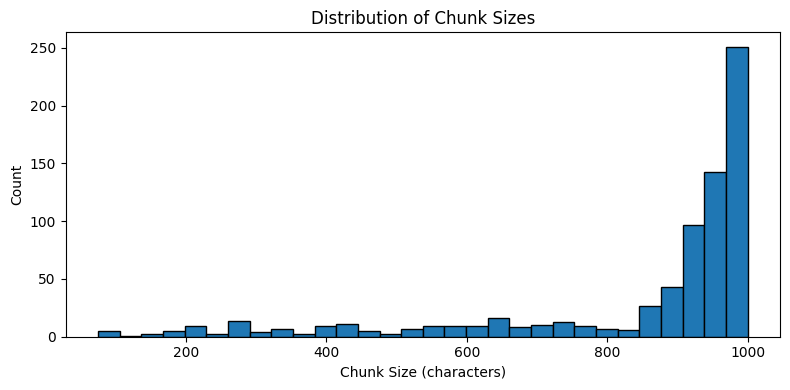

In [26]:
#Histogram of the chunks
plt.figure(figsize=(8, 4))
plt.hist(chunk_sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

#### Generating embeddings using sentence-transformer and stroing in ChromaDB

In [27]:
#This removes the existing vector store to avoid duplication
import shutil
shutil.rmtree("./chroma_db", ignore_errors=True)

CHROMA_DIR = 'chroma_db'

embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vectorstore_1000 = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="assignment3_doc"
)

print(f'Stored {vectorstore_1000._collection.count()} chunks in ChromaDB at {CHROMA_DIR}/')

C:\Users\arves\AppData\Local\Temp\ipykernel_2084\4279969961.py:7: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4056.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stored 742 chunks in ChromaDB at chroma_db/


#### Experimenting with chunk size 200, 2000 and 1000 on 3 sample queries

In [28]:
#Our initial configs for the experiment
#We set up the text splitter with configs for chunk size 200 with varying overlaps

splitter_200  = RecursiveCharacterTextSplitter(chunk_size=200,  chunk_overlap=20)
splitter_2000 = RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)

chunks_200  = splitter_200.split_documents(valid_pages)
chunks_2000 = splitter_2000.split_documents(valid_pages)

print(f'Chunks at size  200 : {len(chunks_200):,}')
print(f'Chunks at size 1000 : {len(chunks):,}')
print(f'Chunks at size 2000 : {len(chunks_2000):,}')

# Build temporary vectorstores for the other chunks created
vectorstore_200  = Chroma.from_documents(chunks_200,  embedding_model, collection_name='experiment_200')
vectorstore_2000 = Chroma.from_documents(chunks_2000, embedding_model, collection_name='experiment_2000')

SAMPLE_QUERIES = [
    "What are the current trends in the yellow taxi service?",
    "How has yellow taxi ridership changed over recent years?",
    "Has the yellow taxi service been performing well?",
]

Chunks at size  200 : 3,493
Chunks at size 1000 : 742
Chunks at size 2000 : 392


In [29]:
#Conducting the experiment

print('\n=== Chunk Size Experiment: Top-3 Retrieved Chunks ===\n')

for query in SAMPLE_QUERIES:
    print(f'Results for Query: "{query}" \n')
    for label, vs in [("200", vectorstore_200), ("1000", vectorstore_1000), ("2000", vectorstore_2000)]:
        print(f"Chunk size:{label} ")
        results = vs.similarity_search(query, k=3)
        for i, doc in enumerate(results):
            print(f"\n--- Result {i+1} (source: {doc.metadata.get('source', 'unknown')}) ---")
            print(doc.page_content[:400])
        print("\n\n")
    print('\n' + '─' * 70 + '\n')



=== Chunk Size Experiment: Top-3 Retrieved Chunks ===

Results for Query: "What are the current trends in the yellow taxi service?" 

Chunk size:200 

--- Result 1 (source: docs\2020-tlc-factbook.pdf) ---
end of 2019. During that time, passenger 
pickups accounted for 53% of all airport 
trips. Passengers utilized Yellow taxis far more
for pickups than drop-offs at airports.

--- Result 2 (source: docs\annual_report_2024.pdf) ---
all taxi hack-ups be WAVs to increase the share of accessible vehicles in the taxi fleet to 50% by the end of 2028. 
Policies, Initiatives, and Agency Highlights

--- Result 3 (source: docs\mobility-report-singlepage-2019.pdf) ---
Street on a daily basis dropped again in 2017.
• Having previously only reported on Yellow Taxi trip totals, 
this year’s Mobility Report has combined all Taxi and For-



Chunk size:1000 

--- Result 1 (source: docs\2020-tlc-factbook.pdf) ---
11
Trip Accessibility and Safety
Accessibility
In 2018 the TLC required all FHV bases 
to 

Chunk size 200 produces small fragments that are suitable for the document provided where information is condensed into smaller text chunks with information this chunk being the most suitable where each chunk has the right amount of context.

Chunk size 1000 adds on additional context that is not needed which dilutes the amount of information present in the reports providing information that is irrelevant to the question.

Chunk Size=2000 can retrieve highly relevant passages but also bundles unrelated topics into the same chunk as information is diluted and the main context of the question is lost.

Chunk size=200 with overlap=20 consistently returned the most relevant top-3 results as it has the right amount of information per chunk without too much information diluting it but still has the revelvant details needed for the question.

### Task 2.3: RAG Pipeline Implementation

#### Prompt Template For RAG Pipeline

In [30]:
RAG_PROMPT = """You are an expert analyst on NYC transportation policy.
Answer the question using ONLY the context provided below and follow these rules:

1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate

Context:
{context}
Question: {question}
Answer:"""

#### Setup and Helper Functions For Pipeline

In [31]:
#Get the environment variables from .env
load_dotenv()

LLM_BASE_URL = os.getenv("LLM_BASE_URL")
LLM_API_KEY = os.getenv("LLM_API_KEY")

client = OpenAI(
 base_url=LLM_BASE_URL,
 api_key=LLM_API_KEY,
)

#The vectorstore is converted into a retriever
retriever = vectorstore_1000.as_retriever(search_kwargs={"k": 4})

In [32]:
#This adds source citations to the documents along with their page number and content
def format_context(docs):
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page", "?")
        context_parts.append(
        f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
        )
    return "\n\n---\n\n".join(context_parts)

#### RAG Pipeline Below

In [33]:
def ask_rag(question):
    #Get relevant chunks
    relevant_chunks = retriever.invoke(question)

    #Add source document and page number
    context = format_context(relevant_chunks)

    #Build the augmented prompt
    prompt = RAG_PROMPT.format(context=context, question=question)

    #Generate the answer
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )
    answer = response.choices[0].message.content
    return answer, relevant_chunks

print("Pipeline implemented")

Pipeline implemented


#### Testing the Pipeline

In [34]:
TEST_QUESTIONS = [
    "What are the TLC requirements for obtaining a taxi driver's licence?",
    "How has the number of yellow taxi trips changed between 2019 and 2023?",
    "What are the current regulations in place for transportation in the NYC",
    "What accessibility requirements must TLC-licensed vehicles meet?",
    "What environmental or green-vehicle initiatives has the TLC introduced?",
]

rag_results = []
for q in TEST_QUESTIONS:
    answer, sources = ask_rag(q)
    print(f"Question asked:  {q}")
    print("Answer given was: \n")
    print(answer)

    print("\nOverview of sources used:")
    i = 0
    for source in sources:
        i +=1
        doc_name = source.metadata.get("source", "Unknown")
        page = source.metadata.get("page", "?")
        print(f"\n[Source ({i})]: {doc_name}, Page {page}")
        print(f"Excerpt: {source.page_content[:200]}...")
    print("\n\n")

Question asked:  What are the TLC requirements for obtaining a taxi driver's licence?
Answer given was: 

To obtain a TLC Driver License, applicants must: 
- be at least 19 years of age [Source 4, Page 1]
- produce a valid government-issued photo ID and a valid Social Security number [Source 4, Page 1]
- have a valid Chauffeur's License [Source 4, Page 1]
- provide an abstract of their driving record if their driver's license was issued by a state other than New York [Source 4, Page 1]
- pass a drug test [Source 2, Page 5] and [Source 3, Page 5]
- have their fingerprints taken [Source 2, Page 5] and [Source 3, Page 5]
- complete a New York State DMV Defensive Driving Course [Source 2, Page 5] and [Source 3, Page 5]
- complete TLC’s 24-Hour Driver’s Education Course [Source 2, Page 5] and [Source 3, Page 5]
- complete a Wheelchair Accessible Vehicle Training course [Source 2, Page 5] and [Source 3, Page 5]
- meet all other requirements for obtaining a new TLC Driver License, including h

### Task 2.4: RAG Evaluation & Analysis

#### Our Test Cases For Evaluating RAG Pipeline

In [35]:
test_cases = [
    {
        "question": "What is the minimum age requirement for a TLC taxi driver licence?",
        "expected_keywords": ["19", "age", "minimum", "licence"],
        "expected_sources": ["nyc-rules-of-the-city"]  
    },
    {
        "question": "What trends exist in the NYC taxi commission right now?",
        "expected_keywords": ["yellow_cab", "increase", "decrease", "electric", "volume"],
        "expected_sources": ["annual_report", "factbook", "report", "electrification"] 
    },
    {
        "question": "How many licensed yellow taxis were operating in NYC in 2023?",
        "expected_keywords": ["taxi", "licensed", "medallion"],
        "expected_sources": ["annual_report", "factbook", "report"] 
    },
    {
        "question": "What is the base fare for a yellow taxi in NYC?",
        "expected_keywords": ["$", "fare", "base", "meter", "yellow_taxi"],
        "expected_sources":  ["nyc-rules-of-the-city"]
    },
    {
        "question": "What are the insurance requirements for TLC-licensed vehicles?",
        "expected_keywords": ["insurance", "liability", "coverage", "FHV", "medallion", "minimum"],
        "expected_sources":  ["report"]
    },
    {
        "question": "How many active FHV licenses were issued after the license cap was lifted?",
        "expected_keywords": ["FHV", "license_cap", "attrition", "active", "issued", "for_hire"],
        "expected_sources": ["annual_report", "factbook", "report"]
    },
    {
        "question": "What are the requirements for a TLC vehicle inspection?",
        "expected_keywords": ["inspection", "vehicle", "safety", "annual", "compliance", "age_limit"],
        "expected_sources":  ["nyc-rules-of-the-city"]
    },
    {
        "question": "What are the wheelchair accessibility requirements for NYC taxis?",
        "expected_keywords": ["WAV", "wheelchair", "accessible", "medallion", "paratransit", "ADA"],
        "expected_sources": ["annual_report", "factbook", "report"]
    },
    {
        "question": "What regulations does the NYC taxi commission follow?",
        "expected_keywords": ["regulations", "driver", "rules", "licence"],
        "expected_sources": ["nyc-rules-of-the-city"]
    },
    {
        "question": "How many safety-related violations have been issued by the Commission?",
        "expected_keywords": ["violations", "safety-related", "unlicensed", "safety"],
        "expected_sources": ["commuter_van_safety"]
    },
]

#### Evaluating Our Test Cases

In [36]:
#Coverage Helper Function
def get_coverage(retrieved, expected):

    hits = sum(1 for expected_source in expected
                      if expected_source.lower() in retrieved)
    
    coverage = hits/ len(expected)
    
    return hits, coverage 

In [37]:
total_source_hits = 0
total_answer_hits = 0

total_expected_source_hits = 0
total_expected_answer_hits = 0

for test in test_cases:
    attempt = 0

    while attempt < 2:
        attempt +=1

        try:
            answer, sources = ask_rag(test["question"])
            break
        except Exception as e:
            error_context = str(e)
            print(f'  Attempt {attempt} failed: {error_context[:120]}')
        
        if attempt ==2:
            print("LLM Model Failed")
            exit(1)

    #Evaluate source retrieval quality
    retrieved_sources = ' '.join(
        source.metadata.get('source', '').lower() for source in sources
    )
    source_hits, source_coverage = get_coverage(retrieved_sources, test['expected_sources'])  

    #Evaluate answer retrieval quality
    answer_lower = answer.lower()
    answer_hits, answer_coverage = get_coverage(answer_lower, test['expected_keywords'])

    total_source_hits += source_hits
    total_answer_hits += answer_hits

    total_expected_source_hits += len(test['expected_sources'])
    total_expected_answer_hits += len(test['expected_keywords'])

    print(f"The test question was: {test['question']}")
    print(f"The total answer coverage was: {(answer_coverage *100):.2f}%")
    print(f"The total source coverage was: {(source_coverage *100):.2f}%")
    print(f"The generated answer(first 300 characters) was: {answer[:300]}\n")


The test question was: What is the minimum age requirement for a TLC taxi driver licence?
The total answer coverage was: 75.00%
The total source coverage was: 100.00%
The generated answer(first 300 characters) was: The minimum age requirement for a TLC Driver License is 19 years of age [Source 1].

The test question was: What trends exist in the NYC taxi commission right now?
The total answer coverage was: 0.00%
The total source coverage was: 50.00%
The generated answer(first 300 characters) was: Based on the provided context, there is no information about current trends in the NYC taxi commission. The context only provides information about annual reports from 2024 and 2025, but does not contain any details about the content of these reports [Source 1, Source 2]. The other sources [Source 3

The test question was: How many licensed yellow taxis were operating in NYC in 2023?
The total answer coverage was: 66.67%
The total source coverage was: 66.67%
The generated answer(first 300 char

In [38]:
#Getting grand total for all test cases
total_answer_coverage = total_answer_hits/total_expected_answer_hits
total_source_coverage = total_source_hits/total_expected_source_hits
total_accuracy = (total_answer_hits + total_source_hits) / (total_expected_answer_hits + total_expected_source_hits)

print(f"The total accuracy for answer retrieval was: {(total_answer_coverage * 100):.2f}")
print(f"The total accuracy for source retrieval was: {(total_source_coverage * 100):.2f}")
print(f"Our overal accuracy for both source and answer retrieval combined is: {(total_accuracy *100):.2f} ")

The total accuracy for answer retrieval was: 46.94
The total accuracy for source retrieval was: 68.42
Our overal accuracy for both source and answer retrieval combined is: 52.94 


In [39]:
print(f"The total retrieval errors were: {total_expected_source_hits - total_source_hits}")
print(f"The total generation failures were: {total_expected_answer_hits - total_answer_hits}")

The total retrieval errors were: 6
The total generation failures were: 26


The total retrieval errors shows how many times our RAG pipeline failed to get the expected source document that was given in the test case by us. Some retrieval erros may be due to inaccurate test cases given however the model lacks the ability to get every major trend at times such as the electric vehicle effort in certain questions. However we sometimes listed the wrong documents for the question while the model retrieved relevant information.

The total generation errors shows how many times our RAG pipeline failed to give the expected keywords provided in our test case in the answer generated. The model displayed a great deal of generation errors where it missed information on the electrical initiative and other trends present in the factbook and reports, however this may be due to the model's inability to understand images and graphs.

Potential improvements can come through better document curation, reduced chunk sizes(due to the small condensed nature of the information) and better test cases.

## Part 3: Integrated Analytics Application

### Task 3.1: Query Router

We create the query router prompt as follows with edge cases being handled inside the template where unrelated or ambiguous prompts are defaulted to hybrid and it is explicity said that it is such

In [40]:
#Creating the Router Prompt Template

CLASSIFICATION_ROUTER_PROMPT = """
    You are a query routing assistant for an NYC taxi analytics system where you must
    classify questions into 3 categories based on the context of the question and keywords:

  DATA —     answerable from structured NYC Yellow Taxi trip records from columns such as 
             fares, distances, trip counts, speeds, tips, pickup/dropoff locations, times.
             An example query is 'What was the average fare on Mondays?'
  DOCUMENT — answerable from NYC transportation policy documents and other related reports or
             documents (TLC regulations, licensing, policy, congestion initiatives, 
             accessibility rules, trends). An example query is 'What are
             the TLC regulations on surge pricing'
  HYBRID   — requires BOTH the structured trip data AND the policy documents to answer
             the query (e.g. comparing actual patterns against policy recommendations)

             
You must also follow the following rules:
  1.If the query is unrelated to NYC taxi data or documents, explicitly say so and default
    to HYBRID.
  2.If the query is ambiguous, explicitly say so and default to HYBRID.
  3.Be concise and accurate

Respond with ONLY valid JSON in this exact format:
{{
  "category": "DATA" | "DOCUMENT" | "HYBRID",
  "reasoning": "one sentence explaining why"
}}

QUESTION: {question}

JSON RESPONSE:
"""

In [41]:
#Test Cases
TEST_CLASSIFICATION_QUERIES = {
    'DATA': [
        "What was the average fare amount on Mondays in January 2024?",
        "Which pickup hour had the highest number of trips?",
        "What is the average trip speed on weekends vs weekdays?",
        "How many trips exceeded 20 miles in distance?",
        "What percentage of passengers gave a tip greater than 20%?",
    ],
    'DOCUMENT': [
        "What are the TLC licensing requirements for new taxi drivers?",
        "What accessibility standards must TLC vehicles comply with?",
        "What environmental initiatives has the TLC introduced for green vehicles?",
        "How does the TLC handle driver misconduct and violations?",
        "What insurance coverage is required for TLC-licensed vehicles?",
    ],
    'HYBRID': [
        "How do actual tipping patterns in the trip data compare to TLC fare recommendations?",
        "Do trips to airports follow the pricing guidelines set out in TLC policy?",
        "How does observed trip speed during peak hours compare to congestion policy targets?",
        "Are short trips under 2 miles consistent with TLC minimum fare regulations?",
        "How does the share of wheelchair-accessible taxi pickups compare to TLC accessibility targets?",
    ],
}

In [42]:
EDGE_CASE_QUERIES = {
    "Why do taxis exist?",
    "Are you a real human being?",
    "Where can I pirate Resident Evil 9?",
    "What are your thoughts on xenos and the emperor of the imperium of mankind?",
    "Tell me about New York City"
}

#### We create the query router function and json formatter function
We will use our existing client from Part 2

In [43]:
import json

def get_json_elements(response):
    obj = json.loads(response)
    return obj["category"], obj["reasoning"]


def route_query(question):
    attempt = 0
    prompt = CLASSIFICATION_ROUTER_PROMPT.format(question=question)

    try:
        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=500,
            temperature=0.2
        )
        answer = response.choices[0].message.content
        return answer
    except Exception as e:
        error_context = str(e)
        print(f'  Attempt {attempt} failed: {error_context[:120]}')

#### Running Our Test Cases On Our LLM model

In [44]:
#Normal Queries

total = 0
correct = 0

for expected_category, questions in TEST_CLASSIFICATION_QUERIES.items():
    print(f'── Expected Category: {expected_category} ──')
    for q in questions:
        attempt = 0

        while attempt < 2:
            attempt +=1

            try:
                result = route_query(q)
                break
            except Exception as e:
                error_context = str(e)
                print(f'  Attempt {attempt} failed: {error_context[:120]}')

            if attempt == 2:
                print("LLM Model failed")
                exit(1)

        category, reasoning = get_json_elements(result)

        correct += int(category == expected_category)
        total += 1

        print(f"Question: {q}")
        print(result)
        print(f"Prediction: {'✅' if bool(correct) else f'❌ (got {result["category"]})'}")
        print("\n\n")

accuracy = correct / total * 100
print(f'CLASSIFICATION ACCURACY: {correct}/{total} = {accuracy:.2f}%')

── Expected Category: DATA ──
Question: What was the average fare amount on Mondays in January 2024?
{
  "category": "DATA",
  "reasoning": "This question can be answered from structured NYC Yellow Taxi trip records by analyzing the fares and trip dates."
}
Prediction: ✅



Question: Which pickup hour had the highest number of trips?
{
  "category": "DATA",
  "reasoning": "This question can be answered by analyzing the structured NYC Yellow Taxi trip records, specifically the pickup times and trip counts."
}
Prediction: ✅



Question: What is the average trip speed on weekends vs weekdays?
{
  "category": "DATA",
  "reasoning": "This question can be answered by analyzing the structured NYC Yellow Taxi trip records, specifically the speeds and times of trips."
}
Prediction: ✅



Question: How many trips exceeded 20 miles in distance?
{
  "category": "DATA",
  "reasoning": "This question can be answered by analyzing the distance column in the structured NYC Yellow Taxi trip records."
}
P

In [45]:
#Edge Case Queries

print('=== Edge Case Handling ===\n')
for q in EDGE_CASE_QUERIES:
    result = route_query(q)
    
    print(f"Question: {q}")
    print(result)
    print("\n\n")
    
print("Edge cases default to HYBRID so both backends are consulted — the safest fallback.")

=== Edge Case Handling ===

Question: Why do taxis exist?
{
  "category": "HYBRID",
  "reasoning": "The query is unrelated to specific NYC taxi data or documents, and requires a broad understanding of the taxi system, which may involve both trip data and policy documents."
}



Question: Are you a real human being?
{
  "category": "HYBRID",
  "reasoning": "The query is unrelated to NYC taxi data or documents, so it is being defaulted to HYBRID."
}



Question: Where can I pirate Resident Evil 9?
{
  "category": "HYBRID",
  "reasoning": "The query is unrelated to NYC taxi data or documents, so it is being defaulted to HYBRID as per the rules."
}



Question: What are your thoughts on xenos and the emperor of the imperium of mankind?
{
  "category": "HYBRID",
  "reasoning": "The query is unrelated to NYC taxi data or documents, so it is being defaulted to HYBRID as per the rules."
}



Question: Tell me about New York City
{
  "category": "HYBRID",
  "reasoning": "The query is unrelated 

### Task 3.2: Data Query Handler

#### Setting Up LLM Prompts For Getting SQL Query 

In [46]:
SCHEMA_DESCRIPTION = """ 
    Table: taxi_trips
    Columns:
    - VendorID              : integer    — vendor id
    - tpep_pickup_datetime  : timestamp  — trip pickup time
    - tpep_dropoff_datetime : timestamp  — trip dropoff time
    - passenger_count       : integer    — number of passengers
    - trip_distance         : double     — trip distance in miles
    - PULocationID          : integer    — TLC pickup zone ID
    - DOLocationID          : integer    — TLC dropoff zone ID
    - fare_amount           : double     — metered fare in USD
    - tip_amount            : double     — tip amount in USD
    - total_amount          : double     — total charge in USD
    - tolls_amount          : double     — the amount for the tolls
    - payment_type          : integer    — 1=credit card, 2=cash, 3=no charge, 4=dispute
    - trip_duration_minutes : double     — derived: trip duration in minutes
    - trip_speed_mph        : double     — derived: average speed in mph
    - pickup_hour           : integer    — derived: hour of pickup (0–23)
    - pickup_day_of_week    : integer    — derived: 1=Sunday … 7=Saturday
    - tip_percentage        : double     — derived: tip / fare * 10
    - Airport_fee           : double     — fee for airport
"""

In [47]:
NL_TO_SQL_TEMPLATE = """
    You are a Spark SQL expert. Generate a valid Spark SQL query for the
    table `taxi_trips` that answers the user's question by using the 
    required columns.

    Schema:
    {schema}

    Errors:
    {error}

    Rules:
    - Use only columns listed above below 'Schema'.
    - Always use ROUND(..., 2) for decimal results.
    - Return ONLY the SQL query with no explanation, no markdown, no backticks.
    - Only return columns relevant to the query.
    - The SQL query returned should be ready to be pasted into a spark.sql()
        code line.
    - Handle any errors given above as well under 'Errors' when generating sql
        for this prompt
    
    QUESTION: {question}

    SQL:
"""

#### Setting Up Prompt For Getting Natural Language Response From SQL

In [48]:
SQL_TO_NL_TEMPLATE = """
    You are a data analyst summarising query results.

    Given the original question and the raw query results below, write a clear,
    concise 2 to 3 line sentence in plain English to explain the results of the
    query.
    
    If an error is present in the error field, handle this error if relevant
    when generating your explanation this time.

    Include specific numbers from the results.

    QUESTION: {question}
    SQL QUERY: {sql}
    RESULTS: {results}
    Errors: {error}

    ANSWER:
"""

#### Test Cases For SQL Segment

In [49]:
SQL_TEST_QUESTIONS = [
    "What was the average fare amount for trips taken on each day of the week?",
    "What are the top 5 pickup hours by total revenue?",
    "How does average tip percentage differ between credit card and cash payments?",
    "What is the average trip speed during morning rush hour (7 to 9am) vs evening rush hour (5 to 7pm)?",
    "Can you make an SQL query for finding the answer to life?", #Designed to Fail
]

#### Handling Natural Language to SQL Query Result

In [50]:
def execute_sql_query(question, error=None):
    prompt = NL_TO_SQL_TEMPLATE.format(question=question, schema=SCHEMA_DESCRIPTION, error=error)

    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )

    sql = response.choices[0].message.content
    query_result = spark.sql(sql)

    columns = query_result.columns
    rows = query_result.collect()

    query_result_str = " | ".join(columns) + "\n"
    query_result_str += "\n".join([" | ".join([str(val) for val in row]) for row in rows])

    return query_result_str, sql

    

#### Handling SQL Query Result to Natural Language Explanation

In [51]:
def get_query_result(question, sql, query_result, error=None):
    prompt = SQL_TO_NL_TEMPLATE.format(question=question, sql=sql, results=query_result, error=error)

    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=500,
        temperature=0.2
    )

    answer = response.choices[0].message.content

    return answer


#### Execute Code On Test Cases

In [52]:
MAX_RETRIES = 2

#Helper Function to handle sql query from start to end of pipeline
#Needed in part 3
def handle_sql_query(question):
    attempt = 0
    error_context = ""

    print(f"Question: {question}")
    while attempt < MAX_RETRIES:
        attempt += 1
        try:
            query_result, sql = execute_sql_query(question, error=error_context)
            answer = get_query_result(question, sql, query_result, error=error_context)

            print(f"SQL Generated: {sql}")
            print(f"Raw Query Result: \n {query_result}")
            print(f"Explanation For Query: {answer} \n\n")

            break
        except Exception as e:
            error_context = str(e)
            print(f'  Attempt {attempt} failed: {error_context[:120]}')
        
        if attempt == 2:
            print("Query could not execute after 2 attempts\n\n")


for question in SQL_TEST_QUESTIONS:
    handle_sql_query(question)
        

Question: What was the average fare amount for trips taken on each day of the week?
SQL Generated: SELECT pickup_day_of_week, ROUND(AVG(fare_amount), 2) AS average_fare_amount FROM taxi_trips GROUP BY pickup_day_of_week ORDER BY pickup_day_of_week
Raw Query Result: 
 pickup_day_of_week | average_fare_amount
1 | 19.41
2 | 19.76
3 | 18.6
4 | 18.38
5 | 18.54
6 | 17.9
7 | 17.24
Explanation For Query: The average fare amount for trips varied by day of the week, ranging from $17.24 on Sundays to $19.76 on Tuesdays, with an overall variation of approximately $2.52 across the week. On average, weekdays had higher fares, with Mondays averaging $19.41 and Fridays $18.54. 


Question: What are the top 5 pickup hours by total revenue?
SQL Generated: SELECT pickup_hour, ROUND(SUM(total_amount), 2) AS total_revenue 
FROM taxi_trips 
GROUP BY pickup_hour 
ORDER BY total_revenue DESC 
LIMIT 5
Raw Query Result: 
 pickup_hour | total_revenue
13 | 5637433.05
14 | 5537016.31
12 | 5502973.64
11 | 5040880.4

### Task 3.3: End-to-End Demo

#### Below is our test cases for the demo

In [53]:
END_TO_END_QUERIES = {
    'DATA': [
        "What was the average fare and tip percentage for trips picked up between midnight and 4am?",
        "Which day of the week had the highest total revenue from taxi trips?",
    ],
    'DOCUMENT': [
        "What are the TLC's requirements for driver background checks?",
        "What measures has the TLC introduced to improve passenger safety in taxis?",
    ],
    'HYBRID': [
        "How do actual tipping rates in the trip data compare to any tipping guidance in TLC policy documents?",
        "How does the observed share of trips to airports compare to what TLC reports say about airport demand?",
    ],
}

#### We then run the appropriate backends for each part of our pipeline (classify, decide, process, output)

In [54]:
for category, questions in END_TO_END_QUERIES.items():
    print(f"----{category}----")
    for question in questions:

        #Classify the question and return category
        result = route_query(question)
        category, reasoning = get_json_elements(result)

        print(f"\nQUESTION:{question.upper()}")
        print(f"The question has been categorized as a {category.lower()} query")
        print(f"Reasoning: {reasoning}\n")

        #Execute Appropriate Backend For category
        if category == "DATA":
            handle_sql_query(question)
        elif category == "DOCUMENT":
            answer, sources = ask_rag(question)

            print(f"The question was: {question}")
            print(f"The generated answer(first 300 characters) was: \n{answer[:300]}\n\n")
        else:
            print("SQL QUERY DATA:")
            handle_sql_query(question)

            answer, sources = ask_rag(question)
            print("DOCUMENT DATA")
            print(f"The generated answer(first 300 characters) from our documents was: \n{answer[:300]}\n\n")



----DATA----

QUESTION:WHAT WAS THE AVERAGE FARE AND TIP PERCENTAGE FOR TRIPS PICKED UP BETWEEN MIDNIGHT AND 4AM?
The question has been categorized as a data query
Reasoning: This query is answerable from structured NYC Yellow Taxi trip records using columns such as fares, tips, and pickup times.

Question: What was the average fare and tip percentage for trips picked up between midnight and 4am?
SQL Generated: SELECT ROUND(AVG(fare_amount), 2) AS average_fare, ROUND(AVG(tip_percentage), 2) AS average_tip_percentage 
FROM taxi_trips 
WHERE pickup_hour BETWEEN 0 AND 4
Raw Query Result: 
 average_fare | average_tip_percentage
19.69 | 24.16
Explanation For Query: The average fare for trips picked up between midnight and 4am was $19.69, with an average tip percentage of 24.16%. This suggests that passengers tend to tip around a quarter of their fare during these early morning hours. 



QUESTION:WHICH DAY OF THE WEEK HAD THE HIGHEST TOTAL REVENUE FROM TAXI TRIPS?
The question has been cate

### Reflection

This system can correctly classify queries as either data, document or hybrid ones consistently with no errors being observed in classification. This tells us that our LLM components are correctly configured and prompted to handle such queries with correct rules being used, correct formatting being done of the prompt and proper wording for the LLM to understand.
We also observe that data generated for data related queries involving SQL are accurate and relevant to the question with queries not being wrong or explained wrongly from the given test cases.

However, it should be noted that for  document related queries our model falls short in terms of its retrieval and accuracy. This may be due to limited number of documents ingested by our model and the quality of information present in said documents. The reports used contain many images and graphs which can’t be read by our model leading to much valuable information being lost. Our model then does not have enough context for all possible queries relating to the NYC taxi commission and their policies or trends leading to useful information being given back to the user

Given more time, the document ingestion backend for our model could be polished more with different chunk sizes being used and more documents being ingested. A work around can also be implemented for when documents contain large amounts of images and graphs so that this information is not lost. Furthermore better quality documents could be curated.

